## **IMPORT LIBRARY**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## **UPLOAD DATASET**

In [8]:
from google.colab import files

df = pd.read_excel('Sample - EU Superstore.xls', engine='xlrd')

## **CHECKING DATASET**

In [9]:
print("Jumlah Baris dan Kolom:")
print(df.shape)

print("\nInfo Dataset:")
print(df.info())

print("\n5 Data Teratas:")
display(df.head())

Jumlah Baris dan Kolom:
(10000, 20)

Info Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 20 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Row ID          10000 non-null  int64         
 1   Order ID        10000 non-null  object        
 2   Order Date      10000 non-null  datetime64[ns]
 3   Dispatch Date   10000 non-null  datetime64[ns]
 4   Delivery Mode   10000 non-null  object        
 5   Customer ID     10000 non-null  object        
 6   Customer Name   10000 non-null  object        
 7   Segment         10000 non-null  object        
 8   City            10000 non-null  object        
 9   State/Province  10000 non-null  object        
 10  Country/Region  10000 non-null  object        
 11  Region          10000 non-null  object        
 12  Product ID      10000 non-null  object        
 13  Category        10000 non-null  object        
 14  Sub-

,Row ID,Order ID,Order Date,Dispatch Date,Delivery Mode,Customer ID,Customer Name,Segment,City,State/Province,Country/Region,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,ES-2022-1311038,2022-02-07,2022-02-11,Standard Class,AS-10045,Aaron Smayling,Corporate,Leeds,England,United Kingdom,North,OFF-ST-10000988,Office Supplies,Storage,"Fellowes Folders, Blue",79.20,3,0.0,39.60
1,2,ES-2022-1311038,2022-02-07,2022-02-11,Standard Class,AS-10045,Aaron Smayling,Corporate,Leeds,England,United Kingdom,North,TEC-AC-10004144,Technology,Accessories,"SanDisk Numeric Keypad, Bluetooth",388.92,7,0.0,0.00
2,3,ES-2022-1311038,2022-02-07,2022-02-11,Standard Class,AS-10045,Aaron Smayling,Corporate,Leeds,England,United Kingdom,North,OFF-LA-10001915,Office Supplies,Labels,"Avery Legal Exhibit Labels, 5000 Label Set",35.19,3,0.0,16.11
3,4,ES-2022-1311038,2022-02-07,2022-02-11,Standard Class,AS-10045,Aaron Smayling,Corporate,Leeds,England,United Kingdom,North,OFF-ST-10004550,Office Supplies,Storage,"Fellowes Folders, Wire Frame",50.94,2,0.0,13.20
4,5,ES-2022-1311038,2022-02-07,2022-02-11,Standard Class,AS-10045,Aaron Smayling,Corporate,Leeds,England,United Kingdom,North,TEC-AC-10004068,Technology,Accessories,"Memorex Memory Card, USB",307.44,3,0.0,73.71


## **CHECK MISSING VALUE** & **DUPLICATION**





In [10]:
print("\nMissing Value:")
print(df.isnull().sum())

duplicate = df.duplicated().sum()

print("\nJumlah Data Duplikat:")
print(duplicate)


Missing Value:
Row ID            0
Order ID          0
Order Date        0
Dispatch Date     0
Delivery Mode     0
Customer ID       0
Customer Name     0
Segment           0
City              0
State/Province    0
Country/Region    0
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Quantity          0
Discount          0
Profit            0
dtype: int64

Jumlah Data Duplikat:
0


**IF DATA HAVE DUPLICATE, DELETE <br>
IF DATA DONT HAVE DUPLICATE, SKIP THIS**

In [11]:
df = df.drop_duplicates()


## **RAPIKAN NAMA KOLOM**

In [12]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

print("\nNama Kolom Baru:")
print(df.columns)


Nama Kolom Baru:
Index(['row_id', 'order_id', 'order_date', 'dispatch_date', 'delivery_mode',
       'customer_id', 'customer_name', 'segment', 'city', 'state/province',
       'country/region', 'region', 'product_id', 'category', 'sub-category',
       'product_name', 'sales', 'quantity', 'discount', 'profit'],
      dtype='object')


## **KONVERSI TIPE TANGGAL (JIKA PERLU)**

In [14]:
df['order_date'] = pd.to_datetime(
    df['order_date'],
    dayfirst=True
)

df['ship_date'] = pd.to_datetime(
    df['ship_date'],
    dayfirst=True
)

KeyError: 'ship_date'

## **TIPE DATA AFTER CLEANING**

In [15]:
print("\nTipe Data:")
print(df.dtypes)


Tipe Data:
row_id                     int64
order_id                  object
order_date        datetime64[ns]
dispatch_date     datetime64[ns]
delivery_mode             object
customer_id               object
customer_name             object
segment                   object
city                      object
state/province            object
country/region            object
region                    object
product_id                object
category                  object
sub-category              object
product_name              object
sales                    float64
quantity                   int64
discount                 float64
profit                   float64
dtype: object


## **CHECK OUTLIER (OPTIONAL)**

In [16]:
numeric_columns = df.select_dtypes(include=np.number)

print("\nStatistik Deskriptif:")
display(numeric_columns.describe())


Statistik Deskriptif:


,row_id,sales,quantity,discount,profit
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,293.808906,3.777300,0.103105,37.282974
std,2886.89568,486.055635,2.203268,0.174782,178.100384
min,1.00000,2.955000,1.000000,0.000000,-3059.820000
25%,2500.75000,49.462500,2.000000,0.000000,1.320000
50%,5000.50000,119.355000,3.000000,0.000000,14.220000
75%,7500.25000,320.708625,5.000000,0.100000,48.510000
max,10000.00000,7958.580000,14.000000,0.850000,3979.080000


## **NEW FEATURE**

In [17]:
df['year'] = df['order_date'].dt.year
df['month'] = df['order_date'].dt.month
df['month_name'] = df['order_date'].dt.month_name()

## **EDA SALES PER TAHUN**

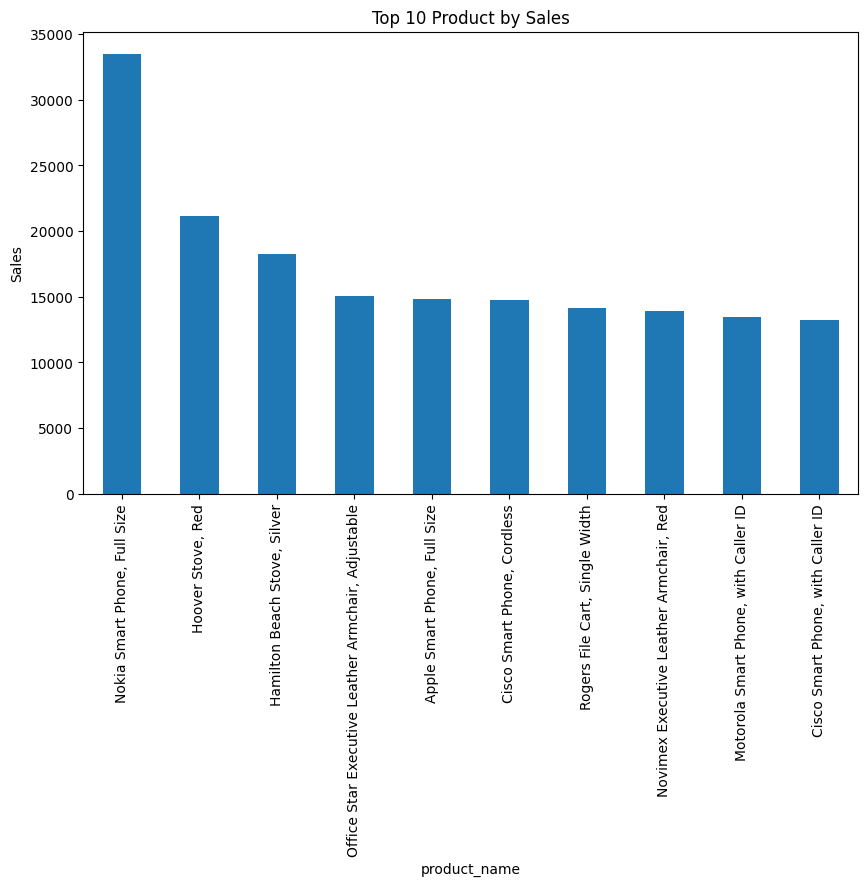

In [18]:
top_product = (
    df.groupby('product_name')['sales']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))
top_product.plot(kind='bar')
plt.title('Top 10 Product by Sales')
plt.ylabel('Sales')
plt.show()

## **EDA SALES PER REGION**

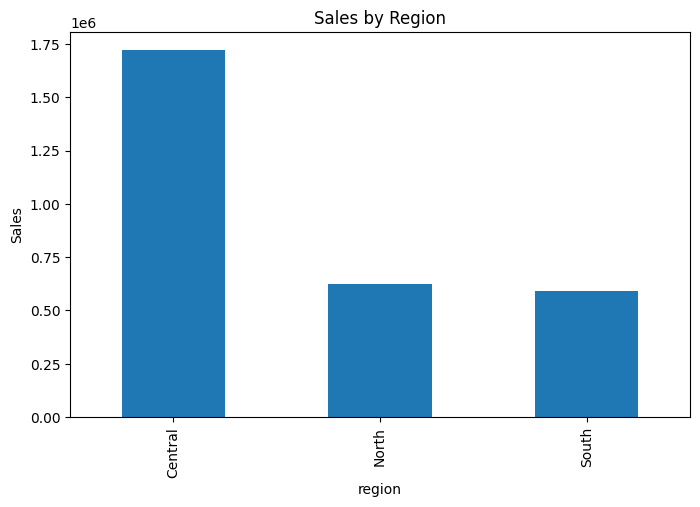

In [19]:
sales_region = df.groupby('region')['sales'].sum()

plt.figure(figsize=(8,5))
sales_region.plot(kind='bar')
plt.title('Sales by Region')
plt.ylabel('Sales')
plt.show()

## **TOP 10 PRODUCT**

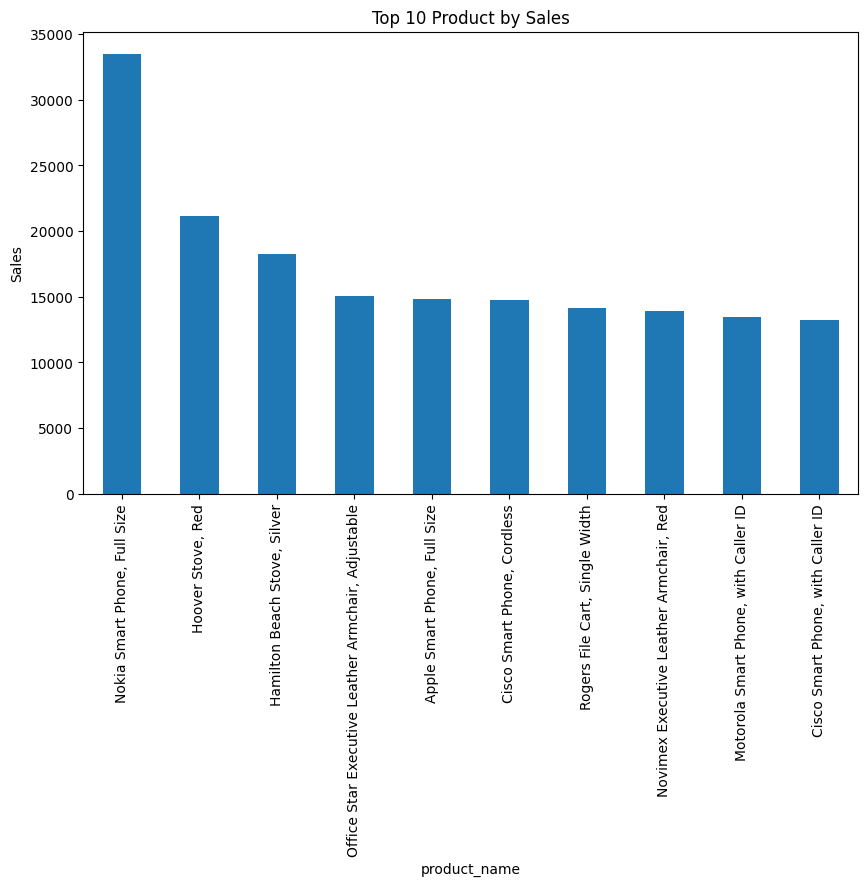

In [20]:
top_product = (
    df.groupby('product_name')['sales']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))
top_product.plot(kind='bar')
plt.title('Top 10 Product by Sales')
plt.ylabel('Sales')
plt.show()

# **TOTAL SALES PER TAHUN**

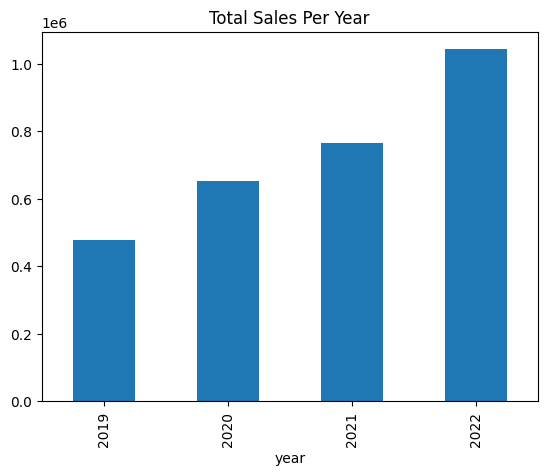

In [21]:
sales_year = df.groupby('year')['sales'].sum()

sales_year.plot(kind='bar')
plt.title('Total Sales Per Year')
plt.show()

## **SAVE DATASET CLEAN**

In [ ]:
df.to_csv(
    'superstore_clean.csv',
    index=False
)

print("\nDataset Bersih Berhasil Disimpan!")


Dataset Bersih Berhasil Disimpan!
